In [4]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2

In [1]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.113"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2,

In [13]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12\tmon'

In [181]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91T810992'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)

True

# System config

In [26]:
idx=0
r=[6058, 5796.46]
q_ch=[5, 7]
config = {'res_ch': 12,
          'ro_chs': [2],
          'res_freqs': [r[idx]],
          'mixer_freq': 5700,
          'res_gains': [0.2],
          'res_phases':[0],
          'ro_phases': [0],
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }

qb_cfg={
    'qb_ch':q_ch[idx],
    'f_ge': 2640.84,
    'qmixer_freq': 2640.84,
    'qb_nqz':2,
    'qb_len':5,
    'qb_gain': 0.01,
    'qb_phase': 0,
    'sigma': 0.05,
    'pi_gain':0,
    'pi2_gain':0,
    'ramsey_freq':2
}

expt_cfg = {
    "reps": 100,
    "soft_avgs": 1000,
    "relax_delay": 50,  # [us]
    "py_avg": 50
}
config = {**config, **qb_cfg, **expt_cfg}


  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 0, 'us')

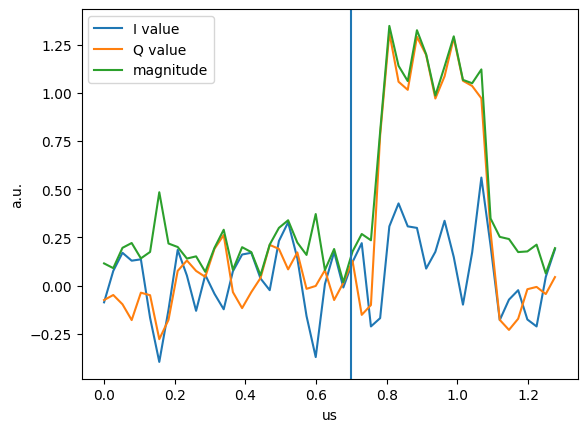

In [9]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':1.3, 
    'res_gains': [1.0], 
    'res_freqs':[5300], 
    'trig_time': 0}) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, rounds=1000)
t = prog.get_time_axis(ro_index=0)


plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.axvline(0.70)
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us")

# OneTone

In [10]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']

        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0],
                      )

    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



  0%|          | 0/101 [00:00<?, ?it/s]

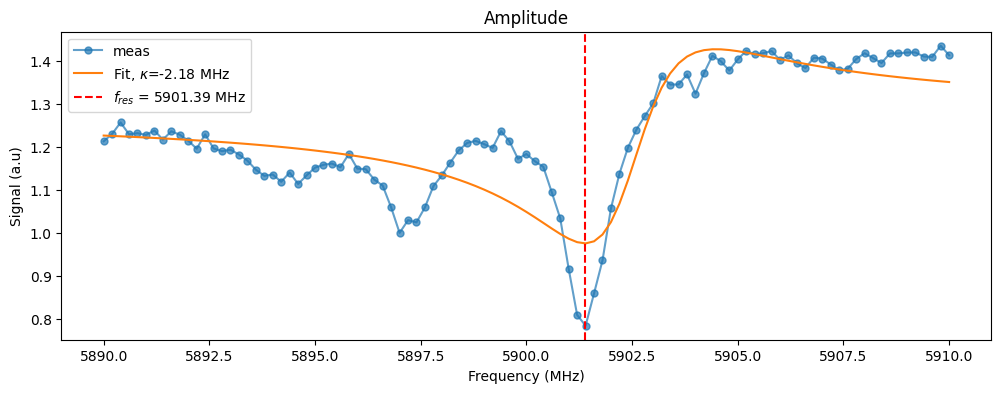

In [100]:
n_roch = 6
F_Span = 10
F_Steps = 101

sweep = np.linspace(-F_Span, F_Span, F_Steps)
# sweep = np.linspace(5600, 6000, 201)
onetone = []
config['res_gains'] = [0.2]
run_cfg={**config}

py_avg = 10
for i in tqdm(sweep):
    # run_cfg['res_freqs'] = np.array(config['res_freqs']) + i
    run_cfg['res_freqs'] =  np.array([5900]) + i
    # run_cfg['res_freqs'] =  [i]
    prog = MuxOneTone(soccfg, reps=run_cfg['reps'], final_delay=0.5, cfg=run_cfg)
    iq_list = prog.acquire(soc, rounds=py_avg, progress=False)
    onetone.append(iq_list[0][0].dot([1, 1j]))

f_res = resonator_analyze(5900 + sweep, onetone)
config['res_freqs'] = [f_res]

# TwoTone

In [101]:
class MuxTwoTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
   

        qb_ch = cfg['qb_ch']
        nqz=cfg['qb_nqz']
        if soccfg['gens'][qb_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qb_ch, nqz=nqz, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qb_ch, nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("freqloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux",
                       style="const",
                       length=cfg["res_len"],
                       mask=[0],
                      )
        ## qb pulse  ##
        self.add_gauss(ch=qb_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qb_ch, name="qb_pulse",
                    style="const",
                    # envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= 0,
                    gain=cfg['qb_gain'],
                    length=cfg["qb_len"],
                    )


    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'], name="qb_pulse", t=0)
        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


span = 300
step = 200
config['res_gains'] = [0.2]
x = 4800
config.update({
    'qb_ch': 5,
    'steps': step,
    'f_ge': x + QickSweep1D("freqloop", -span, span),
    'qmixer_freq': x,
    'qb_nqz':2,
    'qb_len':5,
    'qb_gain': 0.1,
    'sigma':0.05
})

run_cfg = {**config}

  0%|          | 0/50 [00:00<?, ?it/s]

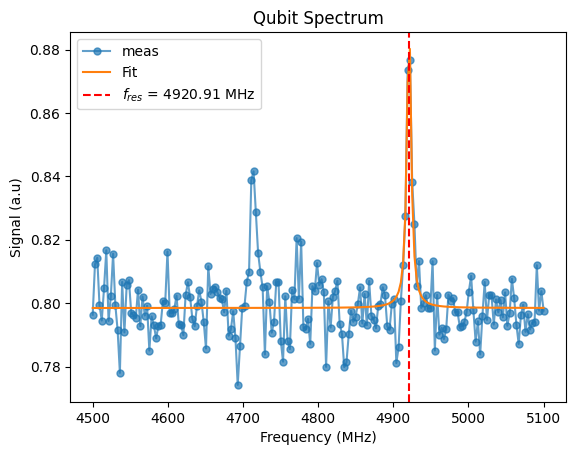

In [102]:
py_avg = 50
prog = MuxTwoTone(soccfg, reps=run_cfg['reps'], final_delay=0.1, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=py_avg)
freqs= prog.get_pulse_param('qb_pulse', 'freq', as_array=True)

f_q = spectrum_analyze(freqs, (iq_list[0][0].dot([1,1j])))
config['f_ge'] = f_q
config['qmixer_freq']=f_q

# Power Rabi

In [103]:
class MuxRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch = cfg['qb_ch']
        nqz=cfg['qb_nqz']
        if soccfg['gens'][qb_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qb_ch, nqz=nqz, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qb_ch, nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("gainloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux",
                       style="const",
                       length=cfg["res_len"],
                       mask=[0],
                      )
        ## qb pulse  ##
        self.add_gauss(ch=qb_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qb_ch, name="qb_pulse",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= 0,
                    gain=cfg['qb_gain'],
                    # length=cfg["qb_len"],
                    )


    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'], name="qb_pulse", t=0)
        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)

  0%|          | 0/20 [00:00<?, ?it/s]

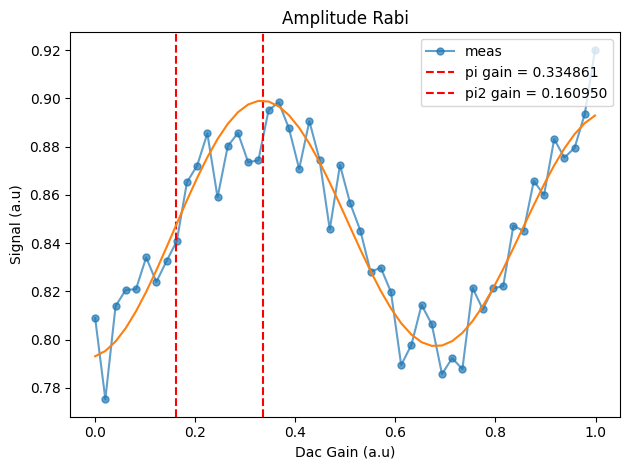

In [109]:
py_avg = 20

STEP = 50
config.update({
    'steps': STEP,
    'qb_gain':QickSweep1D("gainloop", 0, 1),
    'sigma':0.04,
    # 'qb_len':0.2,
    'relax_delay':50,
    'qb_nqz':2
})

run_cfg = {**config}

prog = MuxRabi(soccfg, reps=run_cfg['reps'], final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=py_avg)
gains = prog.get_pulse_param('qb_pulse', 'gain', as_array=True)

config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=None)

# Ramsey

In [110]:
class MuxRamsey(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch = cfg['qb_ch']
        nqz=cfg['qb_nqz']
        if soccfg['gens'][qb_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qb_ch, nqz=nqz, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qb_ch, nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux",
                       style="const",
                       length=cfg["res_len"],
                       mask=[0],
                      )
        ## qb pulse  ##
        self.add_gauss(ch=qb_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qb_ch, name="qb_pi2_pulse1",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'],
                    gain=cfg['pi2_gain'],
                    # length=cfg["q_len"],
                    )
        self.add_pulse(ch=qb_ch, name="qb_pi2_pulse2",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                    gain=cfg['pi2_gain'],
                    # length=cfg["q_len"],
                    )

    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'], name="qb_pi2_pulse1", t=0)
        self.delay_auto(cfg['wait_time'], tag='wait')
        self.pulse(ch=cfg['qb_ch'], name="qb_pi2_pulse2", t=0)
        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


START_TIME = 0. # [us]
STOP_TIME = 1 # [us]
STEP = 50
config.update({
    'steps': STEP,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME),
    'ramsey_freq':1,
    'relax_delay': 50,
})

run_cfg = {**config}


  0%|          | 0/50 [00:00<?, ?it/s]

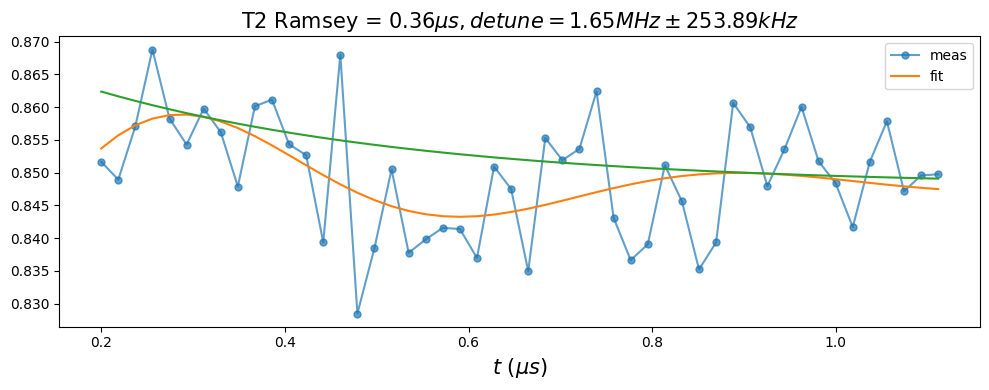

In [112]:
pyavg = 50

ramsey= MuxRamsey(soccfg, reps=run_cfg['reps'], final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, rounds=pyavg, progress=True)
delay_times = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times, ramsey, prefix='Ramsey')

In [89]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.1:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),2)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),2)}')
    else:
        pass

over detune 0.59


# Echo

In [115]:
class MuxEcho(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch = cfg['qb_ch']
        nqz=cfg['qb_nqz']
        if soccfg['gens'][qb_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qb_ch, nqz=nqz, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qb_ch, nqz=nqz)

        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux",
                       style="const",
                       length=cfg["res_len"],
                       mask=[0],
                      )
        ## qb pulse  ##
        self.add_gauss(ch=qb_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qb_ch, name="qb_pi2_pulse1",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'],
                    gain=cfg['pi2_gain'],
                    # length=cfg["q_len"],
                    )
        self.add_pulse(ch=qb_ch, name="qb_pi_pulse",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'],
                    gain=cfg['pi_gain'],
                    # length=cfg["q_len"],
                    )
        self.add_pulse(ch=qb_ch, name="qb_pi2_pulse2",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                    gain=cfg['pi2_gain'],
                    # length=cfg["q_len"],
                    )

    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'], name="qb_pi2_pulse1", t=0)
        self.delay_auto((cfg['wait_time']/2), tag = 'wait1')
        self.pulse(ch=cfg['qb_ch'], name="qb_pi_pulse", t=0)
        self.delay_auto((cfg['wait_time']/2), tag = 'wait2')
        self.pulse(ch=cfg['qb_ch'], name="qb_pi2_pulse2", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


START_TIME = 0. # [us]
STOP_TIME = 5 # [us]
STEP = 100
config.update({
    'steps': STEP,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME),
    'ramsey_freq':1,
    'relax_delay': 50,
})

run_cfg = {**config}


  0%|          | 0/20 [00:00<?, ?it/s]

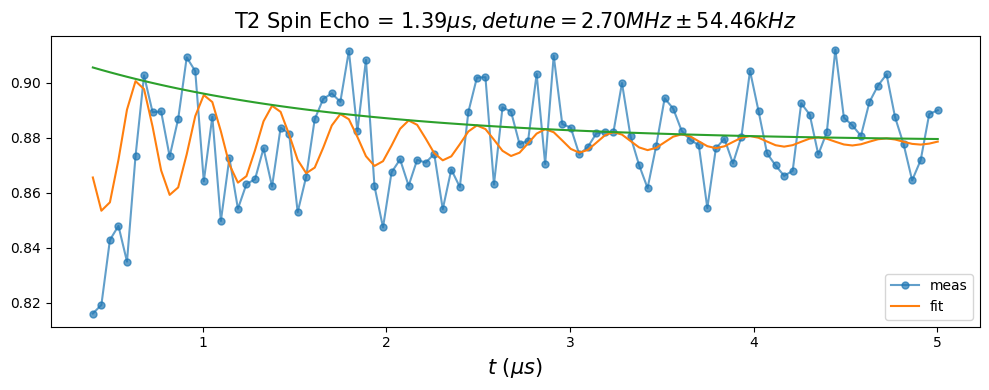

In [118]:
pyavg = 20

spinecho=MuxEcho(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, rounds=pyavg, progress=True)
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo')

# T1

In [113]:
class MuxT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch = cfg['qb_ch']
        nqz=cfg['qb_nqz']
        if soccfg['gens'][qb_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qb_ch, nqz=nqz, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qb_ch, nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0],
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'],
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux",
                       style="const",
                       length=cfg["res_len"],
                       mask=[0],
                      )
        ## qb pulse  ##
        self.add_gauss(ch=qb_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qb_ch, name="qb_pi_pulse",
                    style="arb",
                    envelope='ramp',
                    freq=cfg['f_ge'],
                    phase= cfg['qb_phase'],
                    gain=cfg['pi_gain'],
                    # length=3,
                    )

    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'], name="qb_pi_pulse", t=0)
        self.delay_auto((cfg['wait_time'])+0.01, tag = 'wait')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


START_TIME = 0 # [us]
STOP_TIME = 20 # [us]
STEP = 50
config.update({
    'steps': STEP,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME),
    'relax_delay':50
})

run_cfg = {**config}

  0%|          | 0/20 [00:00<?, ?it/s]

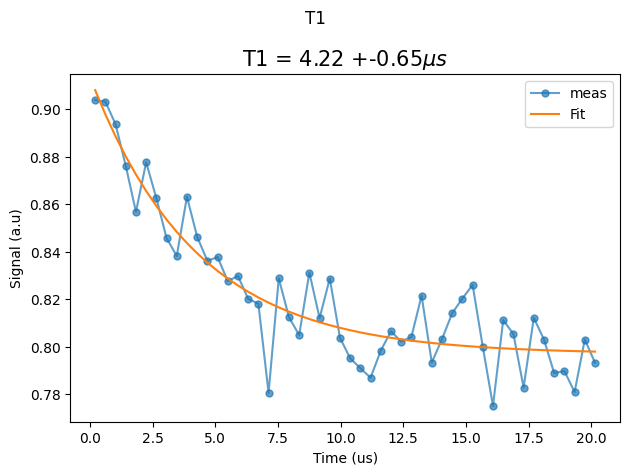

In [114]:
pyavg =20
T1=MuxT1(soccfg, reps=run_cfg['reps'], final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = T1.acquire(soc, rounds=pyavg, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, np.abs(iq_list[0][0].dot([1,1j])))

In [95]:
run_cfg

{'res_ch': 12,
 'ro_chs': [2],
 'res_freqs': [6058.71],
 'mixer_freq': 5700,
 'res_gains': [0.2],
 'res_phases': [0],
 'ro_phases': [0],
 'trig_time': 0.75,
 'res_len': 5,
 'ro_len': 5,
 'qb_ch': 7,
 'f_ge': 4631.389999999999,
 'qmixer_freq': 4630.75,
 'qb_nqz': 2,
 'qb_len': 5,
 'qb_gain': <qick.asm_v2.QickParam at 0x1ca4e416df0>,
 'qb_phase': 0,
 'sigma': 0.04,
 'pi_gain': 0.420391,
 'pi2_gain': 0.208575,
 'ramsey_freq': 4,
 'reps': 100,
 'soft_avgs': 1000,
 'relax_delay': 50,
 'py_avg': 50,
 'steps': 50,
 'wait_time': <qick.asm_v2.QickParam at 0x1ca4f4a5b80>}